# Covariance Estimation and Portfolio Risk

This notebook estimates and analyzes the covariance matrix of asset returns, which is one of the most important inputs in portfolio optimization.

In mean-variance portfolio theory, expected returns determine the potential reward of a portfolio, while the covariance matrix determines how risky the portfolio is.

This notebook focuses on:

1. defining covariance mathematically and intuitively  
2. estimating the sample covariance matrix from historical returns  
3. visualizing covariance structure across assets  
4. connecting covariance to portfolio risk through the formula $w^\top \Sigma w$

The results of this notebook will be used directly in the next stage of the project, where we construct optimized portfolios.

## Motivation

A portfolio is not just a collection of individual assets. Its overall risk depends on how those assets move **relative to one another**.

Two assets may each be volatile on their own, but if they do not move together, combining them can reduce total portfolio risk. This is the fundamental idea behind diversification.

To measure how assets move together, we use **covariance**.

The covariance matrix summarizes:

- the variance of each individual asset
- the covariance between every pair of assets

This matrix is central to mean-variance optimization because portfolio variance is given by

$$
\mathrm{Var}(R_p) = w^\top \Sigma w
$$

where \(w\) is the vector of portfolio weights and \(\Sigma\) is the covariance matrix of asset returns.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 12

pd.options.display.float_format = "{:.6f}".format

## Load Processed Return Data

Rather than downloading market data again, this notebook loads the processed asset returns created in Notebook 1.

This keeps the project modular and ensures that each notebook builds on the outputs of the previous stage.

In [2]:
returns = pd.read_csv("../data/processed/asset_returns.csv", index_col=0, parse_dates=True)

returns.head()

,EFA,GLD,SPY,TLT,VNQ
Date,,,,,
2010-01-05,0.000881,-0.000911,0.002644,0.006438,-0.001123
2010-01-06,0.004218,0.016365,0.000704,-0.013477,-0.001800
2010-01-07,-0.003866,-0.006207,0.004212,0.001680,0.010749
2010-01-08,0.007891,0.004951,0.003322,-0.000447,-0.007377
2010-01-11,0.008176,0.013201,0.001396,-0.005503,0.005817


In [4]:
# Shape check

print("Number of observations:", returns.shape[0])
print("Number of assets:", returns.shape[1])

Number of observations: 4068
Number of assets: 5


## Covariance of Asset Returns

### Mathematical Definition

For two assets with returns $R_i$ and $R_j$, the covariance measures how the two returns move together.

The population covariance is defined as

$$
\mathrm{Cov}(R_i, R_j) =
E[(R_i - \mu_i)(R_j - \mu_j)]
$$

where

- $\mu_i = E[R_i]$
- $\mu_j = E[R_j]$

If the assets tend to move in the same direction, the covariance will be positive.  
If one tends to rise when the other falls, the covariance will be negative.

### Sample Covariance Estimator

In practice we do not know the true covariance of asset returns. Instead, we estimate it using historical data.

Given $T$ observations of returns, the sample covariance estimator is

$$
\hat{\mathrm{Cov}}(R_i, R_j)
=
\frac{1}{T-1}
\sum_{t=1}^{T}
(r_{ti} - \bar r_i)(r_{tj} - \bar r_j)
$$

where

- $r_{ti}$ is the return of asset $i$ at time $t$
- $\bar r_i$ is the average return of asset $i$

The full covariance matrix collects these pairwise covariances for all assets.

In [5]:
cov_matrix = returns.cov()

cov_matrix

,EFA,GLD,SPY,TLT,VNQ
EFA,0.000135,0.000017,0.000108,-0.000032,0.000104
GLD,0.000017,0.000107,0.000006,0.000020,0.000015
SPY,0.000108,0.000006,0.000117,-0.000030,0.000105
TLT,-0.000032,0.000020,-0.000030,0.000090,-0.000011
VNQ,0.000104,0.000015,0.000105,-0.000011,0.000168


The covariance matrix summarizes how the returns of different assets move together.

The diagonal elements represent the **variance of each individual asset's returns**, while the off-diagonal elements represent the **covariance between pairs of assets**, indicating whether they tend to move in the same direction or in opposite directions.

Because the returns are measured in daily decimal units, the covariance values appear small. This is expected, since covariance is measured in squared return units.

Although correlation is often easier to interpret, portfolio risk calculations rely on the covariance matrix because covariance preserves the scale of asset returns.

## Visualizing the Covariance Matrix

While the covariance matrix provides numerical information about how assets move together, visualizing it can make patterns easier to interpret.

A heatmap highlights the magnitude and sign of covariances between assets, allowing us to quickly identify:

- assets that tend to move together
- assets that move in opposite directions
- assets that exhibit relatively independent behavior

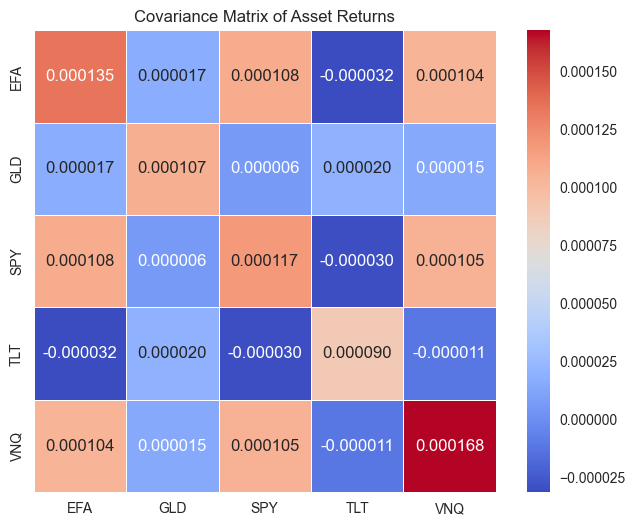

In [6]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cov_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".6f",
    square=True,
    linewidths=0.5
)

plt.title("Covariance Matrix of Asset Returns")

plt.grid(False)
plt.show()

### Interpretation

The covariance heatmap highlights how the returns of different assets move together and how much each asset contributes to overall portfolio risk.

The diagonal elements represent the **variance of each asset's returns**, which indicates their individual volatility. In this dataset, **VNQ and EFA exhibit relatively higher variances**, suggesting greater daily return variability compared with assets such as **TLT**, which shows lower variance.

The off-diagonal elements represent the **covariance between pairs of assets**. Positive covariances between **SPY, EFA, and VNQ** indicate that equity-related assets tend to move together. In contrast, **TLT shows negative covariance with equities**, reflecting its role as a potential hedge during periods when stock markets decline.

These relationships illustrate the basis of **portfolio diversification**, where combining assets with different covariance relationships can reduce overall portfolio risk.

## Portfolio Variance and Risk

### Portfolio Variance

The covariance matrix plays a central role in measuring the risk of a portfolio.

If $w$ represents the vector of portfolio weights and $\Sigma$ is the covariance matrix of asset returns, the variance of the portfolio return is given by

$$
\mathrm{Var}(R_p) = w^\top \Sigma w
$$

where

- $w$ is the vector of asset weights
- $\Sigma$ is the covariance matrix
- $w^\top$ is the transpose of the weight vector

This formula combines the variance of each asset with the covariances between assets to determine the **overall risk of the portfolio**.

The square root of this quantity gives the **portfolio standard deviation**, which is often interpreted as the portfolio's volatility.

### Example Portfolio

In [8]:
# example portfolio weights
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

portfolio_variance = weights.T @ cov_matrix @ weights

portfolio_variance

np.float64(4.874134335096746e-05)

In [9]:
portfolio_volatility = np.sqrt(portfolio_variance)

portfolio_volatility

np.float64(0.0069815000788489194)

### Interpretation

The calculated value represents the **estimated daily volatility of the portfolio**, based on historical return data and the covariance structure between assets.

In this example, we used an equal-weight portfolio across the five assets. The resulting daily volatility is approximately **0.7%**, meaning that the portfolio’s return typically fluctuates by about ±0.7% on a given trading day.

This calculation illustrates how the covariance matrix determines overall portfolio risk. Even if individual assets are volatile, combining assets with different covariance relationships can reduce total portfolio volatility through diversification.

In the next stage of the project, this covariance matrix will be used to construct portfolios that optimize the trade-off between expected return and risk.

## Annualized Covariance Matrix

The covariance matrix computed above reflects **daily return covariances**. 

In portfolio analysis, it is often useful to express risk in **annualized units**. Since there are approximately 252 trading days in a year, the annualized covariance matrix can be obtained by multiplying the daily covariance matrix by 252.

$$
\Sigma_{annual} = 252 \cdot \Sigma_{daily}
$$

In [10]:
annual_cov_matrix = cov_matrix * 252

annual_cov_matrix

,EFA,GLD,SPY,TLT,VNQ
EFA,0.033925,0.004336,0.027214,-0.007964,0.026096
GLD,0.004336,0.026891,0.001482,0.005109,0.003729
SPY,0.027214,0.001482,0.029566,-0.007642,0.026444
TLT,-0.007964,0.005109,-0.007642,0.022621,-0.002891
VNQ,0.026096,0.003729,0.026444,-0.002891,0.042244


In [11]:
annual_volatility = portfolio_volatility * np.sqrt(252)

annual_volatility

np.float64(0.11082787792087244)

### Interpretation

The annualized covariance matrix expresses the relationships between asset returns in **annual risk units** rather than daily units. The diagonal elements represent the **annual variance of each asset**, while the off-diagonal elements capture how pairs of assets move together over time.

Using this covariance structure, the equal-weight portfolio constructed earlier has an estimated **annual volatility of approximately 11%**. This represents the expected magnitude of annual fluctuations in the portfolio's returns based on historical data. The result demonstrates how combining assets with different covariance relationships can produce a diversified portfolio with moderate overall risk.

In [12]:
cov_matrix.to_csv("../data/processed/daily_cov_matrix.csv")
annual_cov_matrix.to_csv("../data/processed/annual_cov_matrix.csv")

---

## Key Takeaways

This notebook introduced the covariance matrix of asset returns and demonstrated how it determines portfolio risk.

Key insights include:

- The covariance matrix summarizes how asset returns move together.
- The diagonal elements represent asset variances, while off-diagonal elements capture pairwise relationships between assets.
- Portfolio risk depends not only on the volatility of individual assets but also on how those assets co-move.
- Diversification reduces risk when assets have lower or negative covariance.

These results provide the foundation for **mean-variance portfolio optimization**, which will be implemented in the next notebook.